In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [ ]:
parkinson_data = pd.read_csv('parkinsons.csv')

In [ ]:
parkinson_data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
parkinson_data.shape

(195, 24)

In [ ]:
parkinson_data.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [ ]:
parkinson_data['status'].value_counts()

,count
status,
1,147
0,48


**Spliting data**

In [ ]:
X = parkinson_data.drop(columns=['name','status'], axis=1)
Y = parkinson_data['status']

In [ ]:
print(X)
print(Y)

     MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0        119.992       157.302        74.997         0.00784   
1        122.400       148.650       113.819         0.00968   
2        116.682       131.111       111.555         0.01050   
3        116.676       137.871       111.366         0.00997   
4        116.014       141.781       110.655         0.01284   
..           ...           ...           ...             ...   
190      174.188       230.978        94.261         0.00459   
191      209.516       253.017        89.488         0.00564   
192      174.688       240.005        74.287         0.01360   
193      198.764       396.961        74.904         0.00740   
194      214.289       260.277        77.973         0.00567   

     MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
0             0.00007   0.00370   0.00554     0.01109       0.04374   
1             0.00008   0.00465   0.00696     0.01394       0.06134   
2             0.00

**Train test split**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3 , stratify=Y , random_state=2)

In [ ]:
print(X.shape , x_train.shape, x_test.shape)

(195, 22) (136, 22) (59, 22)


In [ ]:
# scaler = StandardScaler()
# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

In [ ]:
print(x_train)

     MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
178      148.790       158.359       138.990         0.00309   
135      110.453       127.611       105.554         0.00494   
127      166.888       198.966        79.512         0.00638   
155      117.870       127.349        95.654         0.00647   
49       122.964       130.049       114.676         0.00428   
..           ...           ...           ...             ...   
89       179.711       225.930       144.878         0.00709   
190      174.188       230.978        94.261         0.00459   
146      169.774       191.759       151.451         0.01568   
0        119.992       157.302        74.997         0.00784   
21       153.880       172.860        78.128         0.00480   

     MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
178           0.00002   0.00152   0.00186     0.00456       0.01574   
135           0.00004   0.00244   0.00315     0.00731       0.04128   
127           0.00

**Training model**

In [ ]:
model = svm.SVC(kernel='linear')
model.fit(x_train , y_train)

SVC(kernel='linear')

**Accuracy**

In [ ]:
x_train_prediction = model.predict(x_train)
training_data_accuarcy = accuracy_score(y_train , x_train_prediction)

In [ ]:
print('Accuracy score of training data : ' , training_data_accuarcy)

Accuracy score of training data :  0.875


In [ ]:
x_test_prediction = model.predict(x_test)
test_data_accuarcy = accuracy_score(y_test , x_test_prediction)

In [ ]:
print('Accuracy score of test data : ' , test_data_accuarcy)

Accuracy score of test data :  0.8813559322033898


In [ ]:
input_data = (119.99200,157.30200,74.99700,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.42600,0.02182,0.03130,0.02971,0.06545,0.02211,21.03300,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
# std_data = scaler.transform(input_data_reshaped)
prediction = model.predict(input_data_reshaped)
print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")
else:
  print("The Person has Parkinsons")

The Person has Parkinsons


In [ ]:
import pickle
filename = 'parkinson_model.sav'
pickle.dump(model , open(filename , 'wb'))

**Logistic** **Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(y_train, x_train_prediction)
print('Logistic Regression Training Accuracy:', training_data_accuracy)

x_test_prediction = model.predict(x_test)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)
print('Logistic Regression Test Accuracy:', test_data_accuracy)

Logistic Regression Training Accuracy: 0.8676470588235294
Logistic Regression Test Accuracy: 0.8305084745762712


**Random forest**

In [ ]:
model = RandomForestClassifier(n_estimators=100)
model.fit(x_train, y_train)

x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(y_train, x_train_prediction)
print('Random Forest Training Accuracy:', training_data_accuracy)

x_test_prediction = model.predict(x_test)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)
print('Random Forest Test Accuracy:', test_data_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.8813559322033898


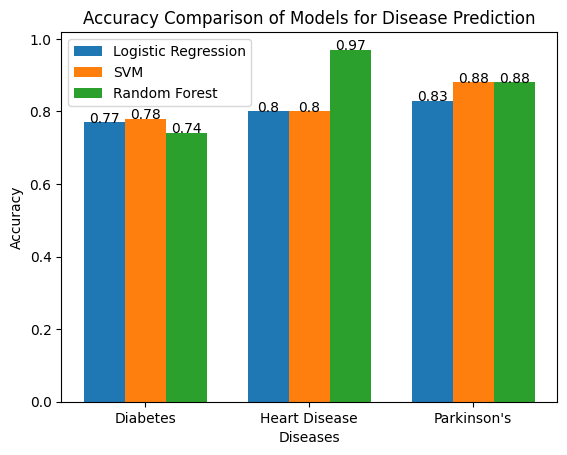

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ================== ENTER YOUR ACCURACIES HERE ==================
# Diabetes
diabetes_lr = 0.77
diabetes_svm = 0.78
diabetes_rf = 0.74

# Heart Disease
heart_lr = 0.80
heart_svm = 0.80
heart_rf = 0.97

# Parkinson's
parkinson_lr = 0.83
parkinson_svm = 0.88
parkinson_rf = 0.88
# ================================================================

# Data for graph
diseases = ['Diabetes', 'Heart Disease', "Parkinson's"]

log_reg = [diabetes_lr, heart_lr, parkinson_lr]
svm = [diabetes_svm, heart_svm, parkinson_svm]
rf = [diabetes_rf, heart_rf, parkinson_rf]

x = np.arange(len(diseases))
width = 0.25

# Create plot
plt.figure()

plt.bar(x - width, log_reg, width, label='Logistic Regression')
plt.bar(x, svm, width, label='SVM')
plt.bar(x + width, rf, width, label='Random Forest')

# Labels & Title
plt.xlabel('Diseases')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Models for Disease Prediction')

plt.xticks(x, diseases)
plt.legend()

# Add values on top of bars
for i in range(len(diseases)):
    plt.text(i - width, log_reg[i], round(log_reg[i], 2), ha='center')
    plt.text(i, svm[i], round(svm[i], 2), ha='center')
    plt.text(i + width, rf[i], round(rf[i], 2), ha='center')

plt.show()

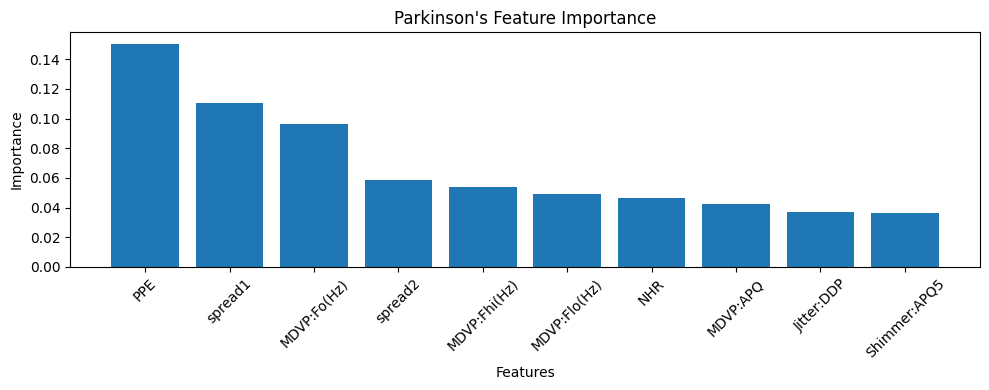

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ---------------- LOAD DATA ----------------
parkinson = pd.read_csv("parkinsons.csv")

# ---------------- PREPARE DATA ----------------
# Drop 'name' (not useful for prediction) + target column
X = parkinson.drop(columns=['name', 'status'])
Y = parkinson['status']

# ---------------- TRAIN MODEL ----------------
model = RandomForestClassifier(n_estimators=100)
model.fit(X, Y)

# ---------------- FEATURE IMPORTANCE ----------------
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort (highest first)
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# OPTIONAL: Top features only (better for report)
feature_importance = feature_importance.head(10)

# ---------------- GRAPH ----------------
plt.figure(figsize=(10, 4))  # 👈 rectangular (wide + short)

plt.bar(feature_importance['Feature'], feature_importance['Importance'])

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title("Parkinson's Feature Importance")

plt.xticks(rotation=45)  # more rotation due to long names

plt.tight_layout()

# Save for report (optional)
# plt.savefig("parkinson_feature_importance.png", dpi=300)

plt.show()